In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


QUANTUM NEURAL NETWORK - ADAPTED TRAINING PIPELINE

LOADING DATA FROM .NPY FILE
Loaded data with shape: (310266, 6)
Selecting first 4 columns as features.
Original unique labels found: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Labels have been converted to binary (0: Benign, 1: Ransomware)

Balancing the dataset...
Balancing to 11038 samples per class.

DATASET SUMMARY
Number of features (qubits): 4
Training/Validation set: 17660 samples
  - Ransomware: 8830
  - Benign: 8830
Holdout test set: 4416 samples
  - Ransomware: 2208
  - Benign: 2208

Configuration:
  - Cross-validation folds: 5
  - Quantum circuit: 4 qubits, 3 layers
  - Training: 25 epochs, batch size 16, lr 0.001

STARTING 5-FOLD CROSS-VALIDATION

Fold 1/5:
  Training samples: 14128, Validation samples: 3532
  Epoch 5/25: Loss=0.3415, Train Acc=0.8684, Val Acc=0.8760
  Epoch 10/25: Loss=0.3269, Train Acc=0.8720, Val Acc=0.8754
  Epoch 15/25: Loss=0.3202, Train Acc=0.8740, Val Acc=0.8751
  Epoch 20/25: Loss=0.3144, 

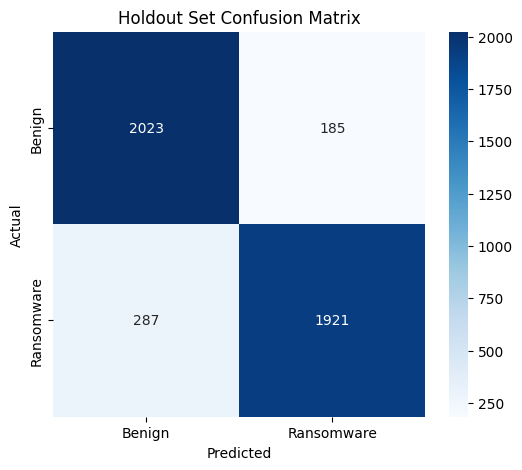


Confusion matrix plot saved as 'qnn_confusion_matrix.png'


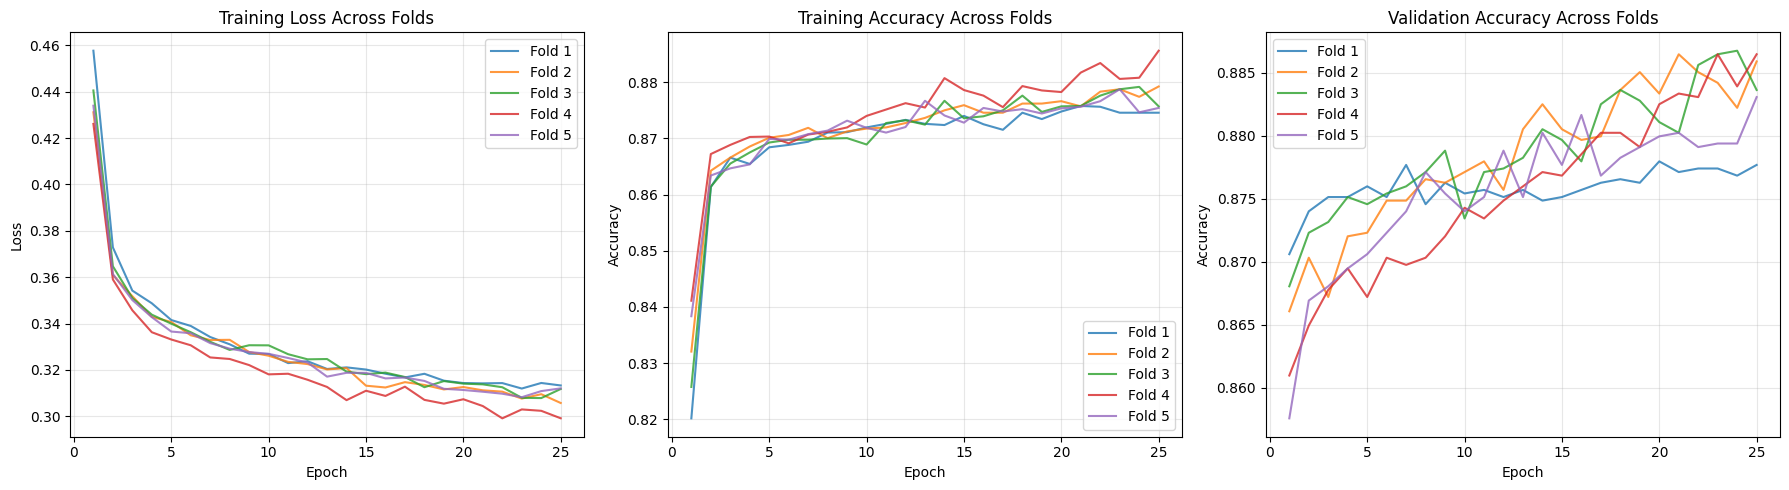


Training history plots saved as 'qnn_training_history.png'


Training pipeline completed successfully!


In [11]:
import torch
import torch.nn as nn
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- QNN Model Definition ---
class QNN(nn.Module):
    def __init__(self, n_qubits, n_layers, n_classes=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.dev = qml.device("lightning.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def circuit(inputs, weights):
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(inputs[i], wires=i)
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RY(weights[l, i, 0], wires=i)
                    qml.RZ(weights[l, i, 1], wires=i)
                    qml.RX(weights[l, i, 2], wires=i)
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit = circuit
        weight_shape = (n_layers, n_qubits, 3)
        self.weights = nn.Parameter(0.01 * torch.randn(weight_shape))
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        q_outputs = [self.circuit(x[i], self.weights) for i in range(batch_size)]
        # --- FIX: Explicitly set the dtype to torch.float32 ---
        quantum_features = torch.stack([torch.tensor(out, dtype=torch.float32) for out in q_outputs])
        return self.classifier(quantum_features)


# --- Data Loading Function ---
def load_data_from_npy(file_path: str, n_features: int, holdout_ratio: float = 0.2):
    """
    Loads data from a .npy file, selects a specific number of features,
    and splits it into training/validation and holdout sets.
    """
    print("\n" + "="*50)
    print("LOADING DATA FROM .NPY FILE")
    print("="*50)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path)
    print(f"Loaded data with shape: {data.shape}")

    print(f"Selecting first {n_features} columns as features.")
    X = data[:, :n_features]
    y = data[:, -1]

    unique_labels = np.unique(y)
    print(f"Original unique labels found: {unique_labels}")
    y_binary = np.where(y == 0, 0, 1)
    print("Labels have been converted to binary (0: Benign, 1: Ransomware)")

    print("\nBalancing the dataset...")
    ransomware_indices = np.where(y_binary == 1)[0]
    benign_indices = np.where(y_binary == 0)[0]
    min_samples = min(len(ransomware_indices), len(benign_indices))
    print(f"Balancing to {min_samples} samples per class.")
    balanced_ransomware_indices = np.random.choice(ransomware_indices, min_samples, replace=False)
    balanced_benign_indices = np.random.choice(benign_indices, min_samples, replace=False)
    balanced_indices = np.concatenate([balanced_ransomware_indices, balanced_benign_indices])
    np.random.shuffle(balanced_indices)
    X_balanced = X[balanced_indices]
    y_balanced = y_binary[balanced_indices]

    X_train_val, X_holdout, y_train_val, y_holdout = train_test_split(
        X_balanced, y_balanced, test_size=holdout_ratio, random_state=42, stratify=y_balanced
    )
    
    print("\n" + "="*50)
    print("DATASET SUMMARY")
    print("="*50)
    print(f"Number of features (qubits): {X_train_val.shape[1]}")
    print(f"Training/Validation set: {len(X_train_val)} samples")
    print(f"  - Ransomware: {np.sum(y_train_val == 1)}")
    print(f"  - Benign: {np.sum(y_train_val == 0)}")
    print(f"Holdout test set: {len(X_holdout)} samples")
    print(f"  - Ransomware: {np.sum(y_holdout == 1)}")
    print(f"  - Benign: {np.sum(y_holdout == 0)}")

    return X_train_val, y_train_val, X_holdout, y_holdout, X_train_val.shape[1]

def evaluate_model(model, X, y, batch_size=8):
    model.eval()
    dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def train_single_fold(X_train, y_train, X_val, y_val, n_qubits, n_layers=3, 
                      epochs=50, batch_size=8, lr=0.001, verbose=True):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_train_quantum = np.tanh(X_train_scaled) * np.pi
    X_val_quantum = np.tanh(X_val_scaled) * np.pi
    
    train_dataset = TensorDataset(torch.FloatTensor(X_train_quantum), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    n_samples_0 = np.sum(y_train == 0)
    n_samples_1 = np.sum(y_train == 1)
    if n_samples_0 > 0 and n_samples_1 > 0:
        weight_for_0 = (n_samples_0 + n_samples_1) / (2.0 * n_samples_0)
        weight_for_1 = (n_samples_0 + n_samples_1) / (2.0 * n_samples_1)
        class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float32)
    else:
        class_weights = None
    
    model = QNN(n_qubits=n_qubits, n_layers=n_layers, n_classes=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_preds, train_labels = [], []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_preds, val_labels = evaluate_model(model, X_val_quantum, y_val, batch_size)
        val_acc = accuracy_score(val_labels, val_preds)
        
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, "
                  f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    
    return model, scaler, history

def cross_validate_qnn(X, y, n_qubits, n_folds=5, n_layers=3, epochs=50, batch_size=8, lr=0.001):
    print("\n" + "="*50)
    print(f"STARTING {n_folds}-FOLD CROSS-VALIDATION")
    print("="*50)
    
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    all_histories = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\nFold {fold}/{n_folds}:")
        print(f"  Training samples: {len(train_idx)}, Validation samples: {len(val_idx)}")
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model, scaler, history = train_single_fold(
            X_train, y_train, X_val, y_val,
            n_qubits=n_qubits, n_layers=n_layers,
            epochs=epochs, batch_size=batch_size, lr=lr
        )
        
        X_val_scaled = scaler.transform(X_val)
        X_val_quantum = np.tanh(X_val_scaled) * np.pi
        val_preds, val_labels = evaluate_model(model, X_val_quantum, y_val, batch_size)
        val_acc = accuracy_score(val_labels, val_preds)
        
        fold_results.append({
            'fold': fold,
            'val_accuracy': val_acc,
            'model': model,
            'scaler': scaler
        })
        all_histories.append(history)
        
        print(f"  Fold {fold} Validation Accuracy: {val_acc:.4f}")
    
    avg_accuracy = np.mean([r['val_accuracy'] for r in fold_results])
    std_accuracy = np.std([r['val_accuracy'] for r in fold_results])
    
    print("\n" + "="*50)
    print("CROSS-VALIDATION RESULTS")
    print("="*50)
    print(f"Average Validation Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")
    
    return fold_results, all_histories

def evaluate_on_holdout(fold_results, X_holdout, y_holdout, batch_size=8):
    print("\n" + "="*50)
    print("FINAL EVALUATION ON HOLDOUT TEST SET")
    print("="*50)
    
    best_fold = max(fold_results, key=lambda x: x['val_accuracy'])
    best_model = best_fold['model']
    best_scaler = best_fold['scaler']
    
    print(f"Using best model from Fold {best_fold['fold']} "
          f"(Val Accuracy: {best_fold['val_accuracy']:.4f})")
    
    X_holdout_scaled = best_scaler.transform(X_holdout)
    X_holdout_quantum = np.tanh(X_holdout_scaled) * np.pi
    
    holdout_preds, holdout_labels = evaluate_model(best_model, X_holdout_quantum, y_holdout, batch_size)
    holdout_acc = accuracy_score(holdout_labels, holdout_preds)
    
    print(f"\nHoldout Test Set Accuracy: {holdout_acc:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(holdout_labels, holdout_preds,
                                target_names=['Benign', 'Ransomware'], 
                                digits=4))
    
    cm = confusion_matrix(holdout_labels, holdout_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'Ransomware'], 
                yticklabels=['Benign', 'Ransomware'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Holdout Set Confusion Matrix')
    plt.savefig('qnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\nConfusion matrix plot saved as 'qnn_confusion_matrix.png'")

def plot_training_history(all_histories):
    try:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for i, history in enumerate(all_histories):
            epochs_range = range(1, len(history['train_loss']) + 1)
            axes[0].plot(epochs_range, history['train_loss'], alpha=0.8, label=f'Fold {i+1}')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss Across Folds')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        for i, history in enumerate(all_histories):
            epochs_range = range(1, len(history['train_acc']) + 1)
            axes[1].plot(epochs_range, history['train_acc'], alpha=0.8, label=f'Fold {i+1}')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training Accuracy Across Folds')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        for i, history in enumerate(all_histories):
            epochs_range = range(1, len(history['val_acc']) + 1)
            axes[2].plot(epochs_range, history['val_acc'], alpha=0.8, label=f'Fold {i+1}')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Accuracy')
        axes[2].set_title('Validation Accuracy Across Folds')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('qnn_training_history.png', dpi=100, bbox_inches='tight')
        plt.show()
        print("\nTraining history plots saved as 'qnn_training_history.png'")
    except Exception as e:
        print(f"Could not create plots: {e}")

def main_training_pipeline(npy_file_path: str, n_qubits_to_use: int, n_folds: int, 
                           n_layers: int, epochs: int, batch_size: int, lr: float):
    print("\n" + "="*60)
    print("QUANTUM NEURAL NETWORK - ADAPTED TRAINING PIPELINE")
    print("="*60)
    
    try:
        X_train_val, y_train_val, X_holdout, y_holdout, n_qubits = load_data_from_npy(
            file_path=npy_file_path,
            n_features=n_qubits_to_use,
            holdout_ratio=0.2
        )
        
        print(f"\nConfiguration:")
        print(f"  - Cross-validation folds: {n_folds}")
        print(f"  - Quantum circuit: {n_qubits} qubits, {n_layers} layers")
        print(f"  - Training: {epochs} epochs, batch size {batch_size}, lr {lr}")
        
        if len(X_train_val) < n_folds * 2:
            print(f"\nERROR: Not enough samples for {n_folds}-fold cross-validation.")
            return None
        
        fold_results, all_histories = cross_validate_qnn(
            X_train_val, y_train_val,
            n_qubits=n_qubits, n_folds=n_folds, n_layers=n_layers,
            epochs=epochs, batch_size=batch_size, lr=lr
        )
        
        if len(X_holdout) > 0:
            evaluate_on_holdout(
                fold_results, X_holdout, y_holdout, batch_size
            )
        
        plot_training_history(all_histories)
        
        best_fold = max(fold_results, key=lambda x: x['val_accuracy'])
        return best_fold['model']
        
    except Exception as e:
        print(f"\nAn error occurred during the training pipeline: {e}")
        import traceback
        traceback.print_exc()
        return None

# --- Main Execution ---
if __name__ == "__main__":
    npy_file = "/kaggle/input/ransap-features-extracted/RANSAP_win7-120gb-hdd_12CLASS (2).npy"
    
    if not os.path.exists(npy_file):
        print(f"FATAL: The file was not found -> '{npy_file}'")
    else:
        model = main_training_pipeline(
            npy_file_path=npy_file,
            n_qubits_to_use=4,
            n_folds=5,
            n_layers=3,
            epochs=25,
            batch_size=16,
            lr=0.001
        )

        if model:
            print("\n\nTraining pipeline completed successfully!")


QUANTUM NEURAL NETWORK - FULL FEATURE TRAINING PIPELINE

LOADING DATA FROM .NPY FILE
Loaded data with shape: (310266, 6)
Using all 5 available columns as features.
Original unique labels found: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Labels have been converted to binary (0: Benign, 1: Ransomware)

Balancing the dataset...
Balancing to 11038 samples per class.

DATASET SUMMARY
Number of features (qubits): 5
Training/Validation set: 17660 samples
  - Ransomware: 8830
  - Benign: 8830
Holdout test set: 4416 samples
  - Ransomware: 2208
  - Benign: 2208

Configuration:
  - Cross-validation folds: 5
  - Quantum circuit: 5 qubits, 3 layers
  - Training: 25 epochs, batch size 16, lr 0.001

STARTING 5-FOLD CROSS-VALIDATION

Fold 1/5:
  Training samples: 14128, Validation samples: 3532
  Epoch 5/25: Loss=0.3888, Train Acc=0.8244, Val Acc=0.8341
  Epoch 10/25: Loss=0.3633, Train Acc=0.8373, Val Acc=0.8448
  Epoch 15/25: Loss=0.3524, Train Acc=0.8436, Val Acc=0.8482
  Epoch 20/25: Loss

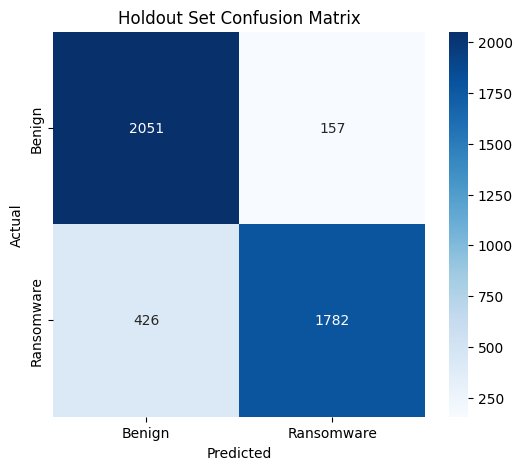


Confusion matrix plot saved as 'qnn_confusion_matrix.png'


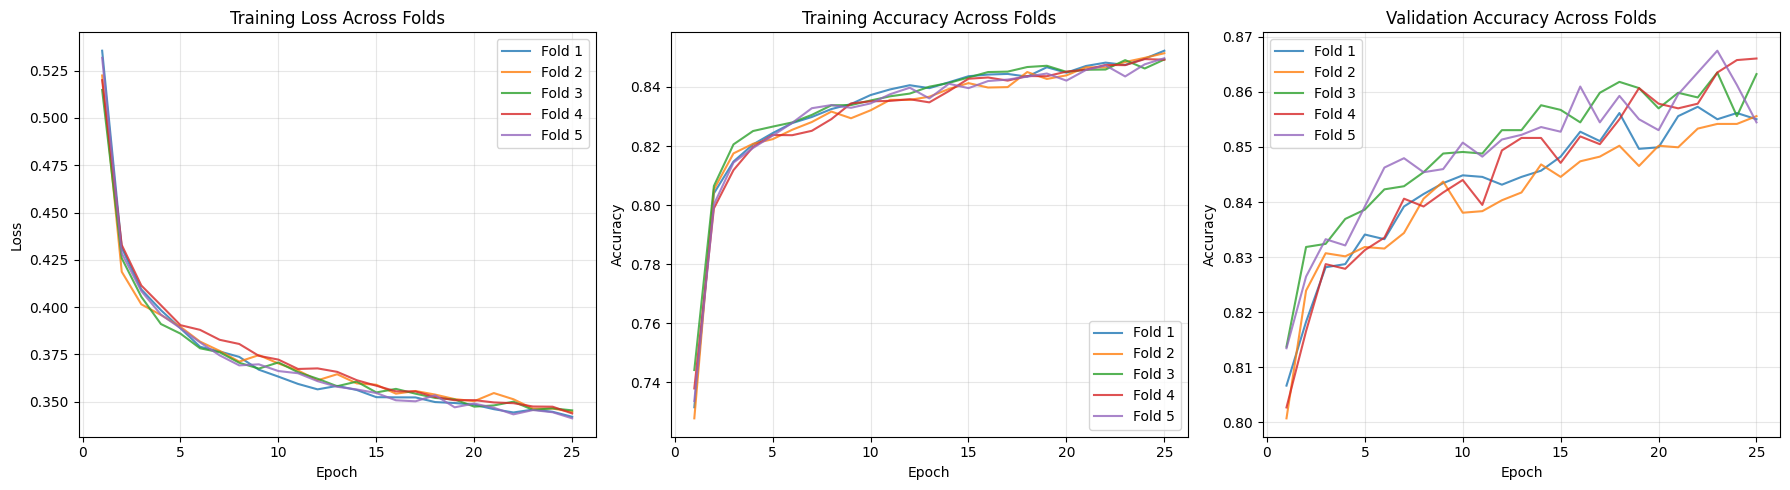


Training history plots saved as 'qnn_training_history.png'


Training pipeline completed successfully!


In [3]:
import torch
import torch.nn as nn
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- QNN Model Definition ---
class QNN(nn.Module):
    def __init__(self, n_qubits, n_layers, n_classes=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        # Using the high-performance lightning.qubit simulator
        self.dev = qml.device("lightning.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def circuit(inputs, weights):
            # Data encoding layer
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(inputs[i], wires=i)
            
            # Variational layers
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RY(weights[l, i, 0], wires=i)
                    qml.RZ(weights[l, i, 1], wires=i)
                    qml.RX(weights[l, i, 2], wires=i)
                # Entangling layer
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0]) # Entangle last and first qubits
            
            # Measurement
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit = circuit
        weight_shape = (n_layers, n_qubits, 3)
        self.weights = nn.Parameter(0.01 * torch.randn(weight_shape))
        
        # Classical post-processing layers
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        # Process each sample in the batch through the quantum circuit
        q_outputs = [self.circuit(x[i], self.weights) for i in range(batch_size)]
        # Convert output to a float32 tensor for the classical layers
        quantum_features = torch.stack([torch.tensor(out, dtype=torch.float32) for out in q_outputs])
        return self.classifier(quantum_features)


# --- Updated Data Loading Function ---
def load_data_from_npy(file_path: str, holdout_ratio: float = 0.2):
    """
    Loads data from a .npy file, using all columns except the last as features,
    and splits it into training/validation and holdout sets.
    """
    print("\n" + "="*50)
    print("LOADING DATA FROM .NPY FILE")
    print("="*50)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path)
    print(f"Loaded data with shape: {data.shape}")

    # Automatically use all columns except the last as features
    X = data[:, :-1]
    y = data[:, -1]
    print(f"Using all {X.shape[1]} available columns as features.")


    # --- Label Transformation ---
    unique_labels = np.unique(y)
    print(f"Original unique labels found: {unique_labels}")
    y_binary = np.where(y == 0, 0, 1) # 0 for benign, 1 for ransomware
    print("Labels have been converted to binary (0: Benign, 1: Ransomware)")

    # --- Balancing the Dataset ---
    print("\nBalancing the dataset...")
    ransomware_indices = np.where(y_binary == 1)[0]
    benign_indices = np.where(y_binary == 0)[0]
    min_samples = min(len(ransomware_indices), len(benign_indices))
    print(f"Balancing to {min_samples} samples per class.")
    balanced_ransomware_indices = np.random.choice(ransomware_indices, min_samples, replace=False)
    balanced_benign_indices = np.random.choice(benign_indices, min_samples, replace=False)
    balanced_indices = np.concatenate([balanced_ransomware_indices, balanced_benign_indices])
    np.random.shuffle(balanced_indices)
    X_balanced = X[balanced_indices]
    y_balanced = y_binary[balanced_indices]

    # --- Splitting Data ---
    X_train_val, X_holdout, y_train_val, y_holdout = train_test_split(
        X_balanced, y_balanced, test_size=holdout_ratio, random_state=42, stratify=y_balanced
    )
    
    print("\n" + "="*50)
    print("DATASET SUMMARY")
    print("="*50)
    print(f"Number of features (qubits): {X_train_val.shape[1]}")
    print(f"Training/Validation set: {len(X_train_val)} samples")
    print(f"  - Ransomware: {np.sum(y_train_val == 1)}")
    print(f"  - Benign: {np.sum(y_train_val == 0)}")
    print(f"Holdout test set: {len(X_holdout)} samples")
    print(f"  - Ransomware: {np.sum(y_holdout == 1)}")
    print(f"  - Benign: {np.sum(y_holdout == 0)}")

    return X_train_val, y_train_val, X_holdout, y_holdout, X_train_val.shape[1]

def evaluate_model(model, X, y, batch_size=8):
    """Evaluates the model on a given dataset."""
    model.eval()
    dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def train_single_fold(X_train, y_train, X_val, y_val, n_qubits, n_layers=3, 
                      epochs=50, batch_size=8, lr=0.001, verbose=True):
    """Trains a model for a single fold of cross-validation."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    # Scale inputs to be in the range [-pi, pi] for quantum circuits
    X_train_quantum = np.tanh(X_train_scaled) * np.pi
    X_val_quantum = np.tanh(X_val_scaled) * np.pi
    
    train_dataset = TensorDataset(torch.FloatTensor(X_train_quantum), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Calculate class weights for imbalanced data
    n_samples_0 = np.sum(y_train == 0)
    n_samples_1 = np.sum(y_train == 1)
    if n_samples_0 > 0 and n_samples_1 > 0:
        weight_for_0 = (n_samples_0 + n_samples_1) / (2.0 * n_samples_0)
        weight_for_1 = (n_samples_0 + n_samples_1) / (2.0 * n_samples_1)
        class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float32)
    else:
        class_weights = None
    
    model = QNN(n_qubits=n_qubits, n_layers=n_layers, n_classes=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_preds, train_labels = [], []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_preds, val_labels = evaluate_model(model, X_val_quantum, y_val, batch_size)
        val_acc = accuracy_score(val_labels, val_preds)
        
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, "
                  f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    
    return model, scaler, history

def cross_validate_qnn(X, y, n_qubits, n_folds=5, n_layers=3, epochs=50, batch_size=8, lr=0.001):
    """Performs k-fold cross-validation."""
    print("\n" + "="*50)
    print(f"STARTING {n_folds}-FOLD CROSS-VALIDATION")
    print("="*50)
    
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    all_histories = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\nFold {fold}/{n_folds}:")
        print(f"  Training samples: {len(train_idx)}, Validation samples: {len(val_idx)}")
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model, scaler, history = train_single_fold(
            X_train, y_train, X_val, y_val,
            n_qubits=n_qubits, n_layers=n_layers,
            epochs=epochs, batch_size=batch_size, lr=lr
        )
        
        val_preds, val_labels = evaluate_model(model, np.tanh(scaler.transform(X_val)) * np.pi, y_val, batch_size)
        val_acc = accuracy_score(val_labels, val_preds)
        
        fold_results.append({
            'fold': fold,
            'val_accuracy': val_acc,
            'model': model,
            'scaler': scaler
        })
        all_histories.append(history)
        
        print(f"  Fold {fold} Validation Accuracy: {val_acc:.4f}")
    
    avg_accuracy = np.mean([r['val_accuracy'] for r in fold_results])
    std_accuracy = np.std([r['val_accuracy'] for r in fold_results])
    
    print("\n" + "="*50)
    print("CROSS-VALIDATION RESULTS")
    print("="*50)
    print(f"Average Validation Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")
    
    return fold_results, all_histories

def evaluate_on_holdout(fold_results, X_holdout, y_holdout, batch_size=8):
    """Evaluates the best model on the holdout test set."""
    print("\n" + "="*50)
    print("FINAL EVALUATION ON HOLDOUT TEST SET")
    print("="*50)
    
    best_fold = max(fold_results, key=lambda x: x['val_accuracy'])
    best_model = best_fold['model']
    best_scaler = best_fold['scaler']
    
    print(f"Using best model from Fold {best_fold['fold']} "
          f"(Val Accuracy: {best_fold['val_accuracy']:.4f})")
    
    X_holdout_quantum = np.tanh(best_scaler.transform(X_holdout)) * np.pi
    
    holdout_preds, holdout_labels = evaluate_model(best_model, X_holdout_quantum, y_holdout, batch_size)
    holdout_acc = accuracy_score(holdout_labels, holdout_preds)
    
    print(f"\nHoldout Test Set Accuracy: {holdout_acc:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(holdout_labels, holdout_preds,
                                target_names=['Benign', 'Ransomware'], 
                                digits=4))
    
    cm = confusion_matrix(holdout_labels, holdout_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'Ransomware'], 
                yticklabels=['Benign', 'Ransomware'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Holdout Set Confusion Matrix')
    plt.savefig('qnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\nConfusion matrix plot saved as 'qnn_confusion_matrix.png'")

def plot_training_history(all_histories):
    """Plots training and validation curves."""
    try:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot loss curves
        for i, history in enumerate(all_histories):
            epochs_range = range(1, len(history['train_loss']) + 1)
            axes[0].plot(epochs_range, history['train_loss'], alpha=0.8, label=f'Fold {i+1}')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss Across Folds')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot training accuracy
        for i, history in enumerate(all_histories):
            epochs_range = range(1, len(history['train_acc']) + 1)
            axes[1].plot(epochs_range, history['train_acc'], alpha=0.8, label=f'Fold {i+1}')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training Accuracy Across Folds')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Plot validation accuracy
        for i, history in enumerate(all_histories):
            epochs_range = range(1, len(history['val_acc']) + 1)
            axes[2].plot(epochs_range, history['val_acc'], alpha=0.8, label=f'Fold {i+1}')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Accuracy')
        axes[2].set_title('Validation Accuracy Across Folds')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('qnn_training_history.png', dpi=100, bbox_inches='tight')
        plt.show()
        print("\nTraining history plots saved as 'qnn_training_history.png'")
    except Exception as e:
        print(f"Could not create plots: {e}")

def main_training_pipeline(npy_file_path: str, n_folds: int, 
                           n_layers: int, epochs: int, batch_size: int, lr: float):
    """Main training pipeline using a pre-processed .npy file."""
    print("\n" + "="*60)
    print("QUANTUM NEURAL NETWORK - FULL FEATURE TRAINING PIPELINE")
    print("="*60)
    
    try:
        # Load data, n_qubits is now determined automatically
        X_train_val, y_train_val, X_holdout, y_holdout, n_qubits = load_data_from_npy(
            file_path=npy_file_path,
            holdout_ratio=0.2
        )
        
        print(f"\nConfiguration:")
        print(f"  - Cross-validation folds: {n_folds}")
        print(f"  - Quantum circuit: {n_qubits} qubits, {n_layers} layers")
        print(f"  - Training: {epochs} epochs, batch size {batch_size}, lr {lr}")
        
        if len(X_train_val) < n_folds * 2:
            print(f"\nERROR: Not enough samples for {n_folds}-fold cross-validation.")
            return None
        
        # Perform cross-validation
        fold_results, all_histories = cross_validate_qnn(
            X_train_val, y_train_val,
            n_qubits=n_qubits, n_folds=n_folds, n_layers=n_layers,
            epochs=epochs, batch_size=batch_size, lr=lr
        )
        
        # Evaluate on the holdout set if it exists
        if len(X_holdout) > 0:
            evaluate_on_holdout(
                fold_results, X_holdout, y_holdout, batch_size
            )
        
        # Plot the results
        plot_training_history(all_histories)
        
        # Return the best performing model
        best_fold = max(fold_results, key=lambda x: x['val_accuracy'])
        return best_fold['model']
        
    except Exception as e:
        print(f"\nAn error occurred during the training pipeline: {e}")
        import traceback
        traceback.print_exc()
        return None

# --- Main Execution ---
if __name__ == "__main__":
    # Ensure this path is correct for your Kaggle environment
    npy_file = "/kaggle/input/ransap-features-extracted/RANSAP_win7-120gb-hdd_12CLASS (2).npy"
    
    if not os.path.exists(npy_file):
        print(f"FATAL: The file was not found -> '{npy_file}'")
    else:
        # Run the training pipeline
        model = main_training_pipeline(
            npy_file_path=npy_file,
            n_folds=5,
            n_layers=3,
            epochs=25,
            batch_size=16,
            lr=0.001
        )

        if model:
            print("\n\nTraining pipeline completed successfully!")
